HELIOS CORN FUTURES CLIMATE KAGGLE

- **Objective**: Encode climate-driven signals about corn futures behaviour (prices, returns, volatility, term structure), so that a supervised model using your features could predict those futures variables well.
- **Evaluation Metric**: Climate-Futures Correlation Score (CFCS)

Commodity Futures & Climate Data

Production share data quantifying each region's contribution to national corn production, providing economic weighting for regional climate risk assessments.

Regional Market Share

Production share data quantifying each region's contribution to national corn production, providing economic weighting for regional climate risk assessments.


In [ ]:
import sys
from pathlib import Path

# Resolve the project root (parent of notebooks/) robustly: Jupyter has
# no __file__, and CWD varies by how this notebook is launched. Try each
# candidate and use whichever one actually contains `src/`.
_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
_project_root = next((c for c in _candidates if (c / "src").is_dir()), None)
if _project_root is None:
    raise RuntimeError(
        "Could not locate the `src/` package from any of "
        f"{[str(c) for c in _candidates]}. Run this notebook from the "
        "project root or notebooks/ directory, or add the project root to "
        "sys.path manually."
    )
sys.path.insert(0, str(_project_root))

# Config


In [ ]:
from src.config import (
    ClimateLabels,
    ConfigLabels,
    FutureLabels,
    INPUT_PATH,
    MetaLabels,
    OUTPUT_PATH,
    SUBMISSION_COLS,
)

[PosixPath('/kaggle/input/forecasting-the-future-the-helios-corn-climate-challenge/corn_climate_risk_futures_daily_master.csv'),
 PosixPath('/kaggle/input/forecasting-the-future-the-helios-corn-climate-challenge/corn_regional_market_share.csv')]

# Setting up


In [3]:
import pandas as pd

futures_data_path = INPUT_PATH / "corn_climate_risk_futures_daily_master.csv"
market_data_path = INPUT_PATH / "corn_regional_market_share.csv"

assert futures_data_path.exists() and market_data_path.exists(), "Couldnt find data files. Pls reconfigure workspace."

futures = pd.read_csv(futures_data_path)
market_shares = pd.read_csv(market_data_path)

# quick loading tests
assert futures["country_name"].nunique() == futures["country_code"].nunique(), "Expected matching country identifiers."
assert futures["region_name"].nunique() == futures["region_id"].nunique(), "Expected matching region identifiers."

# EDA


## Overview


In [19]:
futures.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320661 entries, 0 to 320660
Data columns (total 41 columns):
 #   Column                                                    Non-Null Count   Dtype  
---  ------                                                    --------------   -----  
 0   ID                                                        320661 non-null  object 
 1   crop_name                                                 320661 non-null  object 
 2   country_name                                              320661 non-null  object 
 3   country_code                                              320661 non-null  object 
 4   region_name                                               320661 non-null  object 
 5   region_id                                                 320661 non-null  object 
 6   harvest_period                                            320661 non-null  object 
 7   growing_season_year                                       320661 non-null  int64  
 8   date

In [73]:
market_shares.isna().sum()

country_name                  0
country_code                  0
region_name                   0
region_id                     0
percent_country_production    1
dtype: int64

<Axes: >

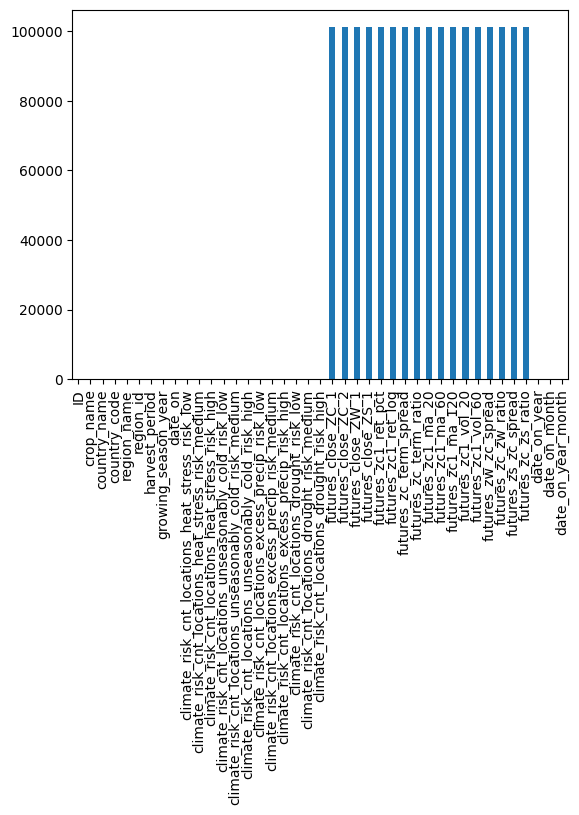

In [21]:
futures.isna().sum().plot(kind="bar")

## Statistical Analysis


In [102]:
futures[ClimateLabels.columns].describe()

,climate_risk_cnt_locations_heat_stress_risk_low,climate_risk_cnt_locations_heat_stress_risk_medium,climate_risk_cnt_locations_heat_stress_risk_high,climate_risk_cnt_locations_unseasonably_cold_risk_low,climate_risk_cnt_locations_unseasonably_cold_risk_medium,climate_risk_cnt_locations_unseasonably_cold_risk_high,climate_risk_cnt_locations_excess_precip_risk_low,climate_risk_cnt_locations_excess_precip_risk_medium,climate_risk_cnt_locations_excess_precip_risk_high,climate_risk_cnt_locations_drought_risk_low,climate_risk_cnt_locations_drought_risk_medium,climate_risk_cnt_locations_drought_risk_high
count,320661.000000,320661.000000,320661.000000,320661.000000,320661.000000,320661.000000,320661.000000,320661.000000,320661.000000,320661.000000,320661.000000,320661.000000
mean,11.499699,0.080733,0.236384,10.429188,0.743383,0.644244,9.934517,1.373666,0.508634,7.603376,3.548093,0.665348
std,9.902119,0.666120,1.534659,9.536199,2.797477,2.847380,9.209405,2.978860,1.820189,8.160940,5.264347,2.054832
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,9.000000,0.000000,0.000000,8.000000,0.000000,0.000000,7.000000,0.000000,0.000000,4.000000,1.000000,0.000000
75%,20.000000,0.000000,0.000000,18.000000,0.000000,0.000000,17.000000,1.000000,0.000000,13.000000,5.000000,0.000000
max,32.000000,22.000000,29.000000,32.000000,32.000000,32.000000,32.000000,28.000000,29.000000,32.000000,32.000000,28.000000


In [103]:
futures[FutureLabels.columns].describe(include="all")

,futures_close_ZC_1,futures_close_ZW_1,futures_close_ZS_1,futures_close_ZC_2,futures_zc1_ret_pct,futures_zc1_ret_log,futures_zc_term_spread,futures_zc_term_ratio,futures_zc1_ma_20,futures_zc1_ma_60,futures_zc1_ma_120,futures_zc1_vol_20,futures_zc1_vol_60
count,219531.000000,219531.000000,219531.000000,219531.000000,219531.000000,219531.000000,219531.000000,219531.000000,219531.000000,219531.000000,219531.000000,219531.000000,219531.000000
mean,454.127871,578.048551,1123.107332,456.351492,0.000199,0.000067,2.223621,1.010926,453.874548,453.421769,453.034423,0.014576,0.015067
std,121.263457,148.799052,240.295615,110.404797,0.016143,0.016336,21.298437,0.036084,120.412401,118.692795,115.980842,0.006966,0.005816
min,301.500000,361.000000,791.000000,312.000000,-0.182432,-0.201422,-145.000000,0.804688,314.075000,321.850000,327.258333,0.004435,0.006106
25%,365.250000,481.750000,932.500000,373.500000,-0.008269,-0.008304,2.750000,1.006085,365.275000,365.387500,366.235417,0.010209,0.011541
50%,406.750000,537.750000,1027.750000,417.750000,0.000539,0.000538,8.000000,1.020445,406.575000,400.066667,396.872917,0.013117,0.013566
75%,525.500000,635.000000,1320.000000,515.250000,0.008671,0.008633,11.750000,1.029010,525.412500,534.275000,535.997917,0.016508,0.016490
max,818.250000,1425.250000,1769.000000,813.500000,0.079582,0.076574,26.000000,1.069815,803.187500,778.750000,739.733333,0.049164,0.038107


## Correlation Analysis


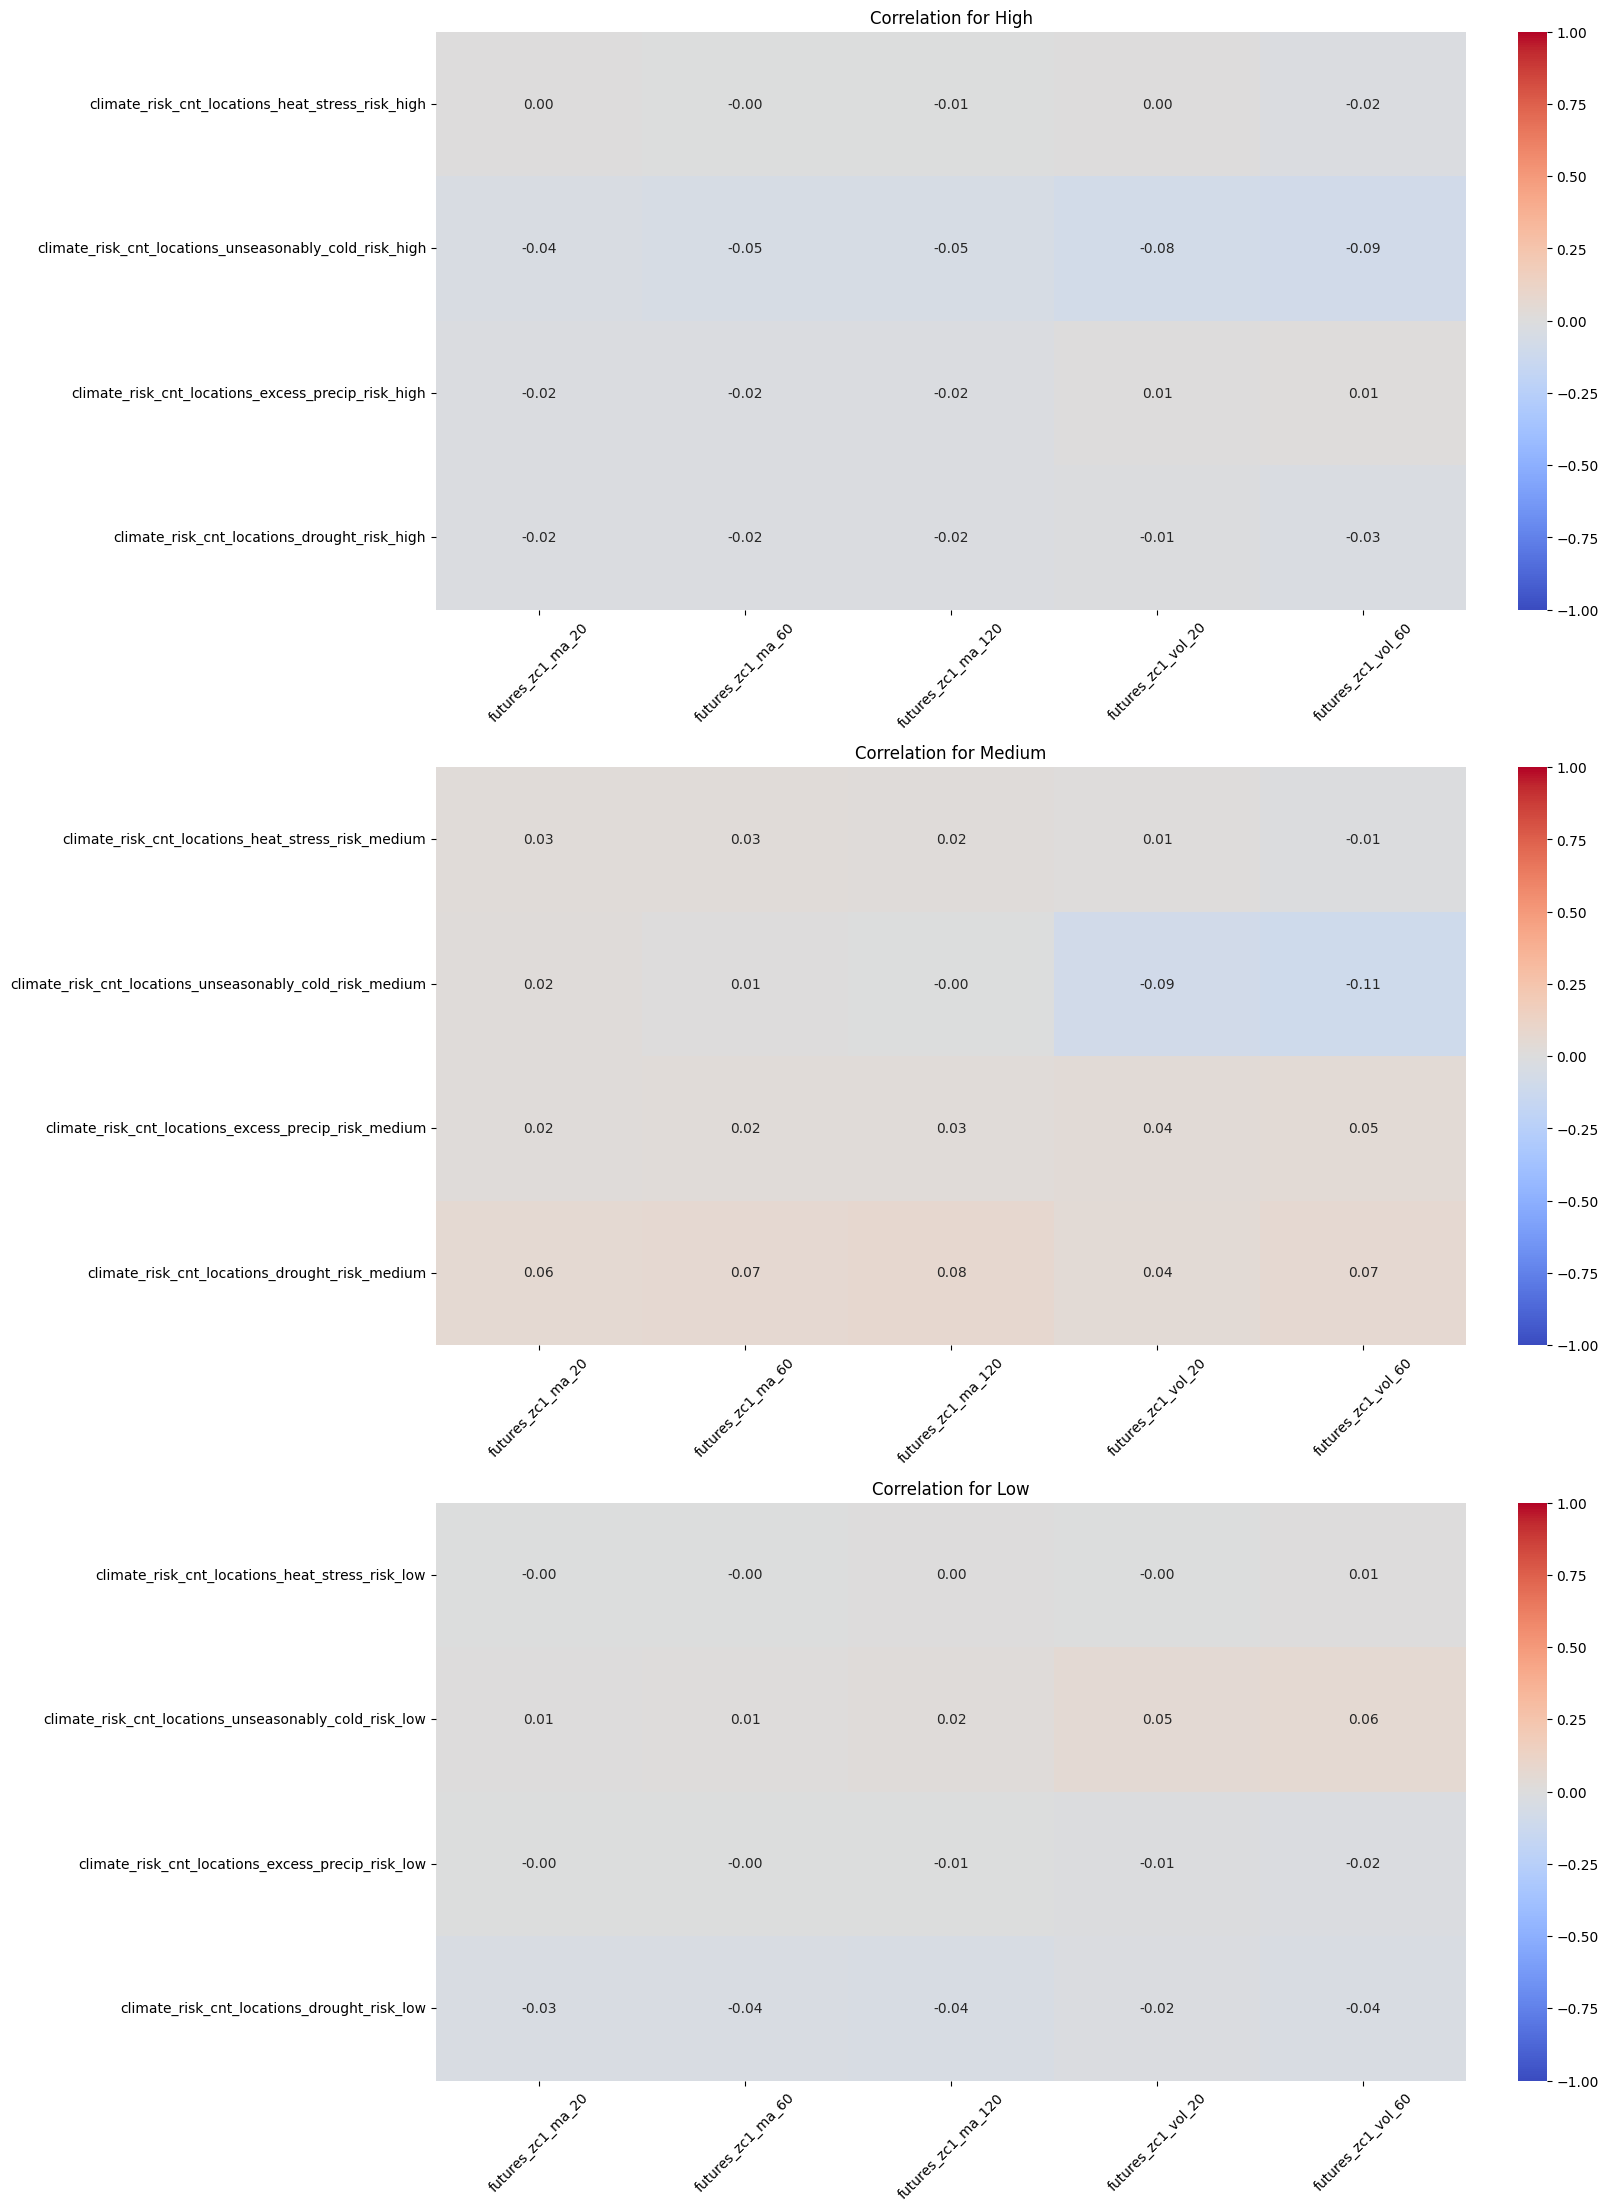

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

def display_corr(title: str, df, input_cols: list, future_cols: list, ax=None, cbar=True):
    title = f"Correlation for {title}"
    corr = df[input_cols + future_cols].corr().loc[input_cols, future_cols]

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 10))

    sns.heatmap(
        corr,
        ax=ax,
        annot=True, fmt=".2f",
        cmap="coolwarm", center=0,
        square=False,          # avoid squashing; set True only if you really want square cells
        annot_kws={"size": 10},
        cbar=cbar,
        vmin=-1, vmax=1        # consistent scale across panels
    )

    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

# --- 3 rows (one column), shared figure ---
fig, axes = plt.subplots(3, 1, figsize=(16, 22), constrained_layout=True)

display_corr("High",   futures, ClimateLabels.extreme_signals, FutureLabels.measures, ax=axes[0], cbar=True)
display_corr("Medium", futures, ClimateLabels.medium_signals,  FutureLabels.measures, ax=axes[1], cbar=True)
display_corr("Low",    futures, ClimateLabels.low_signals,     FutureLabels.measures, ax=axes[2], cbar=True)

plt.show()

# Data Restructuring


Notes:

- 1146 commodity future signals (all existing signals) are missing for 3635 missing percent_country_production values. Reason being is that
- total of 3635 missing percent_country_production values.
- total of 101,136 missing commodity future signals
- total 6 missing `harvest_period` values for only field column,`country_name` values containing "European Union":
  - `df[df.harvest_period.isna()].country_name.value_counts()`


In [5]:
common_cols = list(set(market_shares.columns) - (set(market_shares.columns) - set(futures.columns)))
df = futures.merge(right=market_shares, on=common_cols, how="outer")

# Data Preprocessing


In [157]:
from dataclasses import dataclass, field

@dataclass(slots=True)
class Encoder:
    labels: list = field(init=True, repr=False)
    tag2idx: dict = field(init=False)
    idx2tag: dict = field(init=False)

    def __post_init__(self):
        self.labels = sorted([i.strip() if isinstance(i, str) else "Unknown" for i in self.labels])
        self.tag2idx = {label: idx for idx, label in enumerate(self.labels)}
        self.idx2tag = {idx: label for idx, label in enumerate(self.labels)}

ds = df.dropna(ignore_index=True).copy()

ds["code"] = ds["country_name"] + "_" + ds["region_name"]

country_region_encoder = Encoder(ds.code.unique().tolist())
#country_encoder = Encoder(ds.country_name.unique().tolist())
#region_encoder = Encoder(ds.region_name.unique().tolist())
harvest_encoder = Encoder(ds.harvest_period.unique().tolist())

ds["code"] = ds["code"].map(country_region_encoder.tag2idx)
# ds["country_name"] = ds["country_name"].map(country_encoder.tag2idx)
# ds["region_name"] = ds["region_name"].map(region_encoder.tag2idx)
ds["harvest_period"] = ds["harvest_period"].map(harvest_encoder.tag2idx)
ds["date_on"] = pd.to_datetime(ds["date_on"])

# Feature Engineering


## Flaggers / Indicators & Standardizers


In [158]:
from src.features.selection import select_top_features

X = ds[ConfigLabels.x].values        # climate features
y = ds[ConfigLabels.y[-1]].values    # example target

feature_scores, weights = select_top_features(X, y, ConfigLabels.x, topk=5, ascending=False)

## Temporal Aggregators


In [171]:
from src.features.selection import select_top_features

time_df = ds.set_index("date_on").sort_index(ascending=False)

tds = ["20D", "60D", "120D"]
# NOTE: `NEW_COLS` is referenced but never defined anywhere in this
# notebook -- this raises NameError on a fresh run. It looks like it was
# meant to be additional engineered columns supplementing ConfigLabels.x;
# define it before running this cell.
all_inputs = list(set(ConfigLabels.x + NEW_COLS))

to_keep = set()
weights = []

for y_label in FutureLabels.close_prices + FutureLabels.measures:
    for t in tds:
        x_ = time_df.groupby("code")[all_inputs].rolling(t).mean().dropna().reset_index(0, drop=True)
        y_ = time_df.groupby("code")[y_label].rolling(t).mean().dropna().reset_index(0, drop=True)

        # NOTE: ascending=True keeps the *lowest*-scoring features here --
        # see select_top_features's docstring for why this looks like a
        # bug, preserved rather than silently changed.
        ft, wts = select_top_features(x_, y_, x_cols=all_inputs, topk=2, ascending=True)

        if len(ft["feature"].tolist()) > 0:
            for item in ft["feature"].tolist():
                to_keep.add(item)
            weights.append(wts)

In [173]:
to_keep

{'climate_risk_cnt_locations_drought_risk_high_flagger',
 'climate_risk_cnt_locations_excess_precip_risk_low_coeff',
 'climate_risk_cnt_locations_excess_precip_risk_low_scaled',
 'climate_risk_cnt_locations_heat_stress_risk_high',
 'climate_risk_cnt_locations_heat_stress_risk_high_coeff',
 'climate_risk_cnt_locations_heat_stress_risk_high_scaled',
 'climate_risk_cnt_locations_heat_stress_risk_low',
 'climate_risk_cnt_locations_heat_stress_risk_low_flagger',
 'climate_risk_cnt_locations_heat_stress_risk_low_scaled',
 'climate_risk_cnt_locations_unseasonably_cold_risk_medium',
 'climate_risk_cnt_locations_unseasonably_cold_risk_medium_scaled',
 'harvest_period',
 'harvest_period_coeff'}

# Mock Evaluation


## Draft


In [ ]:
from src.features.selection import top_correlated_pairs

k = 10
D = 5.0

topk = top_correlated_pairs(ds, x_cols=ConfigLabels.x, y_cols=ConfigLabels.y, k=k, steepness=D)

In [387]:
for (x,y), voted_cor in topk.items():
    print(x, y, voted_cor)


harvest_period futures_zc1_vol_60 0.7045692142939816
harvest_period futures_zc1_vol_20 0.6350420754375459
climate_risk_cnt_locations_unseasonably_cold_risk_medium futures_zc1_vol_60 0.6327039267433763
climate_risk_cnt_locations_unseasonably_cold_risk_high futures_zc1_vol_60 0.6080376854099787
climate_risk_cnt_locations_unseasonably_cold_risk_medium futures_zc1_vol_20 0.6074257528889655
climate_risk_cnt_locations_unseasonably_cold_risk_high futures_zc1_vol_20 0.6028944912442387
climate_risk_cnt_locations_drought_risk_medium futures_zc1_ma_120 0.5956904298239366
climate_risk_cnt_locations_drought_risk_medium futures_zc1_ma_60 0.585742086638471
climate_risk_cnt_locations_drought_risk_medium futures_zc1_vol_60 0.5831569194754526
climate_risk_cnt_locations_drought_risk_medium futures_zc1_ma_20 0.577509926620346


In [388]:
pairs.reset_index().rename(columns={"level_0": "x_col", "level_1": "top_y_col", 0: "corr"})["corr"]

0     0.704569
1     0.635042
2     0.632704
3     0.608038
4     0.607426
        ...   
60    0.501205
61    0.500851
62    0.500723
63    0.500127
64    0.500076
Name: corr, Length: 65, dtype: float64

## Metric


In [1]:
import numpy as np
import pandas as pd


def mock_evaluation_metric(
    df: pd.DataFrame,
    x_cols: list,
    y_cols: list,
    top_n_corr: int = 10,
) -> dict:
    """
    Mock Helios CFCS-style evaluation metric, generalized to arbitrary X (features) and Y (targets).

    df : pd.DataFrame
        DataFrame containing both feature and target columns.
    x_cols : list of str
        Feature column names (e.g., climate features you want to evaluate).
    y_cols : list of str
        Target column names (e.g., futures_* series, returns, vol).
    top_n_corr : int
        Number of strongest |corr| values used for overall_strength.
    """

    if (set(x_cols) - set(df.columns)) or (set(y_cols) - set(df.columns)):
        raise ValueError("Missing cols in input dataframe")

    report = {
            "cfcs": None,
            "overall_strength": None,
            "max_corr": None,
            "breadth": None,
            "avg_sig_score": None,
            "max_corr_score": None,
            "n_x_features": len(x_cols),
            "n_y_features": len(y_cols)
        }

    # 2. Correlation matrix (X + Y)
    corr = df[x_cols + y_cols].corr().loc[x_cols, y_cols]
    abs_corr = corr.abs().map(lambda x: 1/(1+np.exp(x*-D)))
    mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle incl diagonal
    pairs = abs_corr.mask(mask).stack().sort_values(ascending=False) # type: ignore
    topk = pairs.head(top_n_corr)   # index is (var1, var2), value is corr

    overall_strength = report["overall_strength"] = topk.mean()
    max_corr = report["max_corr"] = topk.max()
    breadth = report["breadth"] = abs(np.diff(topk)).mean()

    report["cfcs"] = 0.6 * overall_strength + 0.2 * max_corr + 0.2 * breadth

    return report

print("Evaluation Summary: Original Climate Features")
mock_evaluation_metric(ds, x_cols=ConfigLabels.x, y_cols=ConfigLabels.y)

Evaluation Summary: Original Climate Features


NameError: name 'ds' is not defined

# Eval Metric from Submission Template

In [149]:
SIG_THRESHOLD = 0.5
x_cols = list(to_keep)
y_cols = ConfigLabels.y

total_count = N = len(x_cols)
valid_corrs = ds[x_cols + y_cols].corr().loc[y_cols, x_cols].reset_index(0, drop=True)

if len(valid_corrs) == 0:
    raise ValueError("Error generating submission file.")

# Calculate base metrics
abs_corrs = valid_corrs.abs()
max_abs_corr = abs_corrs.max(axis=1)
significant_corrs = max_abs_corr[max_abs_corr >= SIG_THRESHOLD]
significant_count = len(significant_corrs)

# Calculate component scores - ONLY average significant correlations
avg_sig_corr = significant_corrs.mean() * 100 if significant_count > 0 else 0
avg_sig_score = 0.0 if avg_sig_corr != 0.0 else avg_sig_corr * 100

max_corr_score = max_abs_corr.min() * 100  # Cap at 100 when max reaches 1.0
sig_count_score = (significant_count / total_count) * 100  # Percentage

# Composite score: Focus more on quality of significant correlations
cfcs = (0.5 * avg_sig_score) + (0.3 * max_corr_score) + (0.2 * sig_count_score)

score_results = {
    'cfcs_score': round(cfcs, 2),
    'avg_significant_correlation': round(avg_sig_score, 4),
    'max_abs_correlation': round(max_corr_score, 4),
    'significant_correlations_pct': round(sig_count_score/100, 2),
    'avg_sig_score': round(avg_sig_score, 2),
    'max_corr_score': round(max_corr_score, 2),
    'sig_count_score': round(sig_count_score, 2),
    'total_correlations': total_count,
    'significant_correlations': significant_count
}

score_results

{'cfcs_score': 0.34,
 'avg_significant_correlation': 0,
 'max_abs_correlation': 1.1248,
 'significant_correlations_pct': 0.0,
 'avg_sig_score': 0,
 'max_corr_score': 1.12,
 'sig_count_score': 0.0,
 'total_correlations': 11,
 'significant_correlations': 0}

In [13]:
abs_corrs

,harvest_period,climate_risk_cnt_locations_heat_stress_risk_low,climate_risk_cnt_locations_heat_stress_risk_medium,climate_risk_cnt_locations_heat_stress_risk_high,climate_risk_cnt_locations_unseasonably_cold_risk_low,climate_risk_cnt_locations_unseasonably_cold_risk_medium,climate_risk_cnt_locations_unseasonably_cold_risk_high,climate_risk_cnt_locations_excess_precip_risk_low,climate_risk_cnt_locations_excess_precip_risk_medium,climate_risk_cnt_locations_excess_precip_risk_high,climate_risk_cnt_locations_drought_risk_low,climate_risk_cnt_locations_drought_risk_medium,climate_risk_cnt_locations_drought_risk_high
0,0.032894,0.001034,0.028698,0.000061,0.006246,0.021011,0.038351,0.000964,0.019552,0.022396,0.034637,0.062512,0.018861
1,0.001328,0.000578,0.026886,0.001630,0.013491,0.007034,0.048789,0.002768,0.024075,0.020365,0.038665,0.069278,0.019934
2,0.018469,0.000681,0.021118,0.007071,0.017087,0.003773,0.050238,0.005568,0.031074,0.017645,0.044043,0.077508,0.019652
3,0.110782,0.000102,0.008297,0.001414,0.050965,0.087301,0.083508,0.012615,0.037270,0.005995,0.021831,0.040044,0.013026
4,0.173830,0.005435,0.014308,0.020907,0.059034,0.108767,0.087814,0.016178,0.046713,0.011268,0.035534,0.067149,0.025785
